<a href="https://colab.research.google.com/github/Nousheen-code/Supervised-Learning-Model-Implementation/blob/main/Supervised_Learning_Model_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import kagglehub
path = kagglehub.dataset_download("chitwanmanchanda/fraudulent-transactions-data")
import pandas  as pd
import os
print(os.listdir(path))
df=pd.read_csv(os.path.join(path,"Fraud.csv"))
df.info()
#df.head(10)


['Fraud.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
print(df.shape)
df.isnull().sum()

(6362620, 11)


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df_clean=df.copy()
df_clean.duplicated().sum()
df_clean.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [109]:
df_clean.isnull().sum() [df_clean.isnull().sum() > 0]

,0


In [116]:
df_clean.shape
df_clean.columns
df_clean.head()
df_clean.describe()
df_clean.dtypes

,0
step,int64
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64
isFlaggedFraud,int64
type_CASH_OUT,bool
type_DEBIT,bool


In [ ]:
df_clean['isFraud'].value_counts()
df_clean['isFraud'].value_counts(normalize=True) * 100


,proportion
isFraud,
0,99.870918
1,0.129082


In [ ]:
df_clean['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [ ]:
df_clean['nameOrig'].nunique()
df_clean['nameDest'].nunique()

2722362

In [111]:
df_clean.duplicated().sum()
#df_clean = df_clean.drop_duplicates()

np.int64(0)

In [ ]:
df_clean['isFraud'].value_counts()
df_clean['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


In [ ]:
df_clean = df_clean.drop(
    columns=['nameOrig', 'nameDest'],
    errors='ignore'
)
print(df_clean.columns.tolist())

['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (5090096, 11)
X_test: (1272524, 11)

y_train:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

y_test:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [94]:
# 1. Remove ID columns if they still exist
df_clean = df_clean.drop(
    columns=['nameOrig', 'nameDest'],
    errors='ignore'
)

# 2. Separate features and target
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

# 3. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Check everything
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X shape: (6362077, 15)
y shape: (6362077,)
X_train: (5089661, 15)
X_test: (1272416, 15)

Training target:
isFraud
0    5083103
1       6558
Name: count, dtype: int64

Testing target:
isFraud
0    1270777
1       1639
Name: count, dtype: int64


In [ ]:
print(df_clean.columns.tolist())


print(df_clean.dtypes)

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
step                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
type_CASH_OUT        bool
type_DEBIT           bool
type_PAYMENT         bool
type_TRANSFER        bool
dtype: object


In [ ]:
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6362077, 11)
y shape: (6362077,)


In [ ]:
# Feature 1: change in origin account balance
df_clean['orig_balance_change'] = (
    df_clean['oldbalanceOrg'] - df_clean['newbalanceOrig']
)

# Feature 2: change in destination account balance
df_clean['dest_balance_change'] = (
    df_clean['newbalanceDest'] - df_clean['oldbalanceDest']
)

# Feature 3: origin balance error
df_clean['orig_balance_error'] = (
    df_clean['oldbalanceOrg']
    - df_clean['amount']
    - df_clean['newbalanceOrig']
)

# Feature 4: destination balance error
df_clean['dest_balance_error'] = (
    df_clean['newbalanceDest']
    - df_clean['oldbalanceDest']
    - df_clean['amount']
)

print(df_clean.columns.tolist())

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'orig_balance_change', 'dest_balance_change', 'orig_balance_error', 'dest_balance_error']


In [ ]:
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5089661, 15)
(1272416, 15)


In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Scaling completed")

X_train_scaled: (5089661, 15)
X_test_scaled: (1272416, 15)
Scaling completed


In [97]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)
print("Training completed")

Training completed


In [ ]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270777
           1       0.03      0.98      0.05      1639

    accuracy                           0.95   1272416
   macro avg       0.51      0.97      0.51   1272416
weighted avg       1.00      0.95      0.97   1272416



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1210446   60331]
 [     33    1606]]


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9946461464156661
PR-AUC: 0.5993252923727335


In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270777
           1       0.03      0.98      0.05      1639

    accuracy                           0.95   1272416
   macro avg       0.51      0.97      0.51   1272416
weighted avg       1.00      0.95      0.97   1272416

[[1210446   60331]
 [     33    1606]]
ROC-AUC: 0.9946461464156661
PR-AUC: 0.5993252923727335


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use a smaller sample for cross-validation
X_cv = X_train_scaled[:500000]
y_cv = y_train.iloc[:500000]
from sklearn.model_selection import train_test_split

X_cv, _, y_cv, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=500000,
    random_state=42,
    stratify=y_train
)

print(X_cv.shape)
print(y_cv.shape)

(500000, 15)
(500000,)


In [90]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = cross_validate(
    cv_model,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(
        f"{metric}: "
        f"{scores.mean():.4f} "
        f"(± {scores.std():.4f})"
    )

accuracy: 0.9574 (± 0.0022)
precision: 0.0286 (± 0.0014)
recall: 0.9721 (± 0.0066)
f1: 0.0556 (± 0.0026)
roc_auc: 0.9891 (± 0.0015)
pr_auc: 0.6180 (± 0.0387)


In [84]:
print(X_train.shape)

(5089661, 15)


In [93]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nPR-AUC:")
print(average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270777
           1       0.03      0.98      0.05      1639

    accuracy                           0.95   1272416
   macro avg       0.51      0.97      0.51   1272416
weighted avg       1.00      0.95      0.97   1272416


Confusion Matrix:
[[1210446   60331]
 [     33    1606]]

ROC-AUC:
0.9946461464156661

PR-AUC:
0.5993252923727335


In [91]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
import pandas as pd

results = {
    'Logistic Regression': {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    }
}

results_df = pd.DataFrame(results).T

print(results_df)

                     Precision    Recall        F1   ROC-AUC    PR-AUC
Logistic Regression    0.02593  0.979866  0.050522  0.994646  0.599325


In [98]:
from sklearn.model_selection import train_test_split

X_cv, _, y_cv, _ = train_test_split(
    X,
    y,
    train_size=100000,
    random_state=42,
    stratify=y
)

print("CV dataset shape:", X_cv.shape)
print("\nClass distribution:")
print(y_cv.value_counts())

CV dataset shape: (100000, 15)

Class distribution:
isFraud
0    99871
1      129
Name: count, dtype: int64


In [99]:
from sklearn.preprocessing import StandardScaler

cv_scaler = StandardScaler()

X_cv_scaled = cv_scaler.fit_transform(X_cv)

print("CV scaling completed")

CV scaling completed


In [100]:
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(
    class_weight='balanced',
    max_iter=100,
    random_state=42
)

In [101]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results = cross_validate(
    cv_model,
    X_cv_scaled,
    y_cv,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Cross-validation completed")

Cross-validation completed


In [102]:
for metric in scoring:
    scores = cv_results[f'test_{metric}']

    print(
        f"{metric}: "
        f"{scores.mean():.4f} "
        f"(± {scores.std():.4f})"
    )

precision: 0.0291 (± 0.0003)
recall: 1.0000 (± 0.0000)
f1: 0.0566 (± 0.0005)
roc_auc: 0.9974 (± 0.0002)
pr_auc: 0.7318 (± 0.0277)


In [103]:
class_weight='balanced'

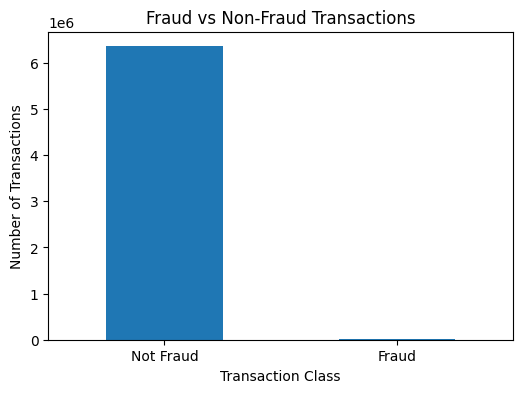

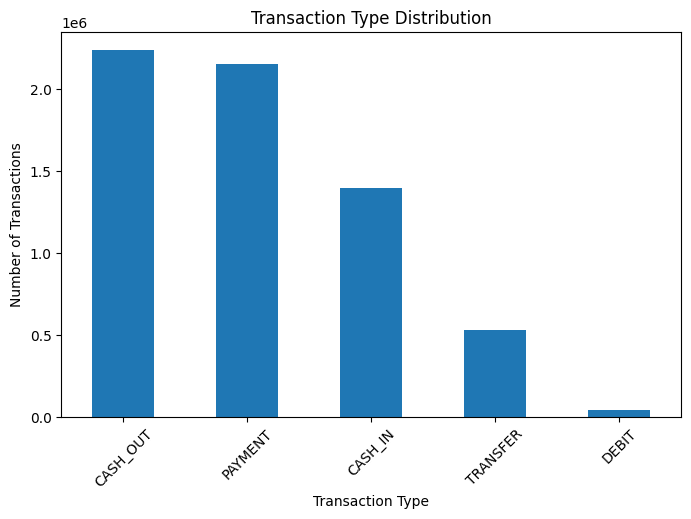

In [105]:
import matplotlib.pyplot as plt

fraud_counts = y.value_counts()

plt.figure(figsize=(6,4))
fraud_counts.plot(kind='bar')

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks(
    ticks=[0, 1],
    labels=['Not Fraud', 'Fraud'],
    rotation=0
)

plt.show()

plt.figure(figsize=(8,5))

df['type'].value_counts().plot(kind='bar')

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()

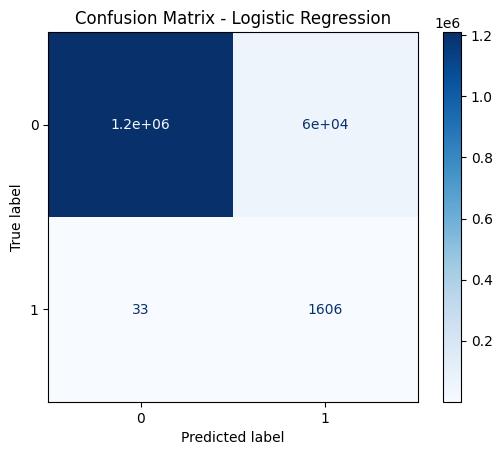

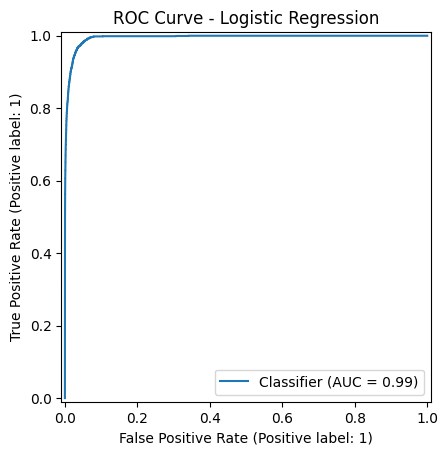

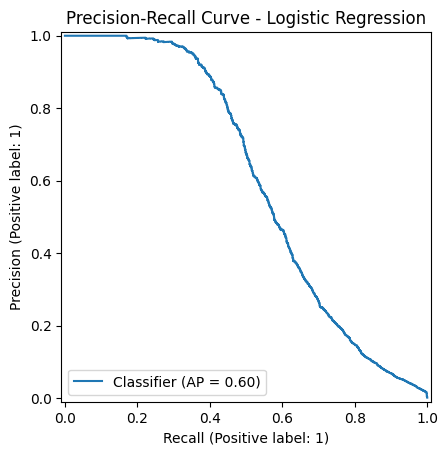

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('ROC Curve - Logistic Regression')
plt.show()

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

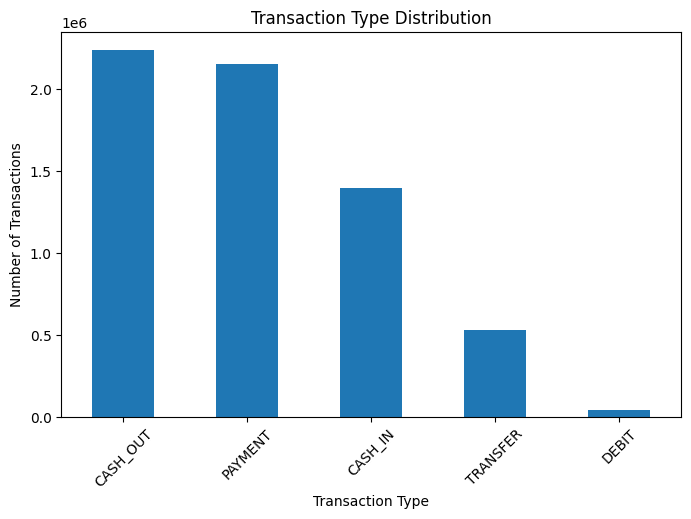

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['type'].value_counts().plot(kind='bar')

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.show()